# Model Tester

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
import sys
import math
import logging
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
from pixell import reproject, lensing, enmap, utils

sys.path.append("/users/stevensonb/Research/tools/deepsphere-cosmo-tf2")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf

tf.get_logger().setLevel(logging.ERROR)

from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten,
    LeakyReLU,
    Add,
    BatchNormalization,
)
from tensorflow.keras.callbacks import EarlyStopping, TerminateOnNaN, TensorBoard
from tensorflow.keras.optimizers import AdamW, Adam
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts, ExponentialDecay

from deepsphere import HealpyGCNN
from deepsphere.healpy_layers import (
    HealpyChebyshev,
    HealpyPool,
    Healpy_ResidualLayer,
    HealpyPseudoConv_Transpose,
)

from mlpng import Core
from mlpng.utils import (
    setup_logging,
    try_init_wandb,
    get_data,
    make_trainer_plots,
    PowerSpectrumLoss,
    PowerSpectrumLoss2,
    RMSELoss,
    RMSELoss2,
    rmse_metrics,
)
from mlpng.utils.dataloaders import MapDataset, UnlensMapDataset, PhiMapDataset

from mlpng.scn_jorik import get_model as get_fnl_model

logger = setup_logging("mlpng.notebook", level=logging.DEBUG)

In [3]:
print("Conda environment:", os.environ["CONDA_DEFAULT_ENV"])
print("Python executable:", sys.executable)
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA version: {tf.sysconfig.get_build_info()['cuda_version']}")
print(f"cuDNN version: {tf.sysconfig.get_build_info()['cudnn_version']}")

Conda environment: ds25
Python executable: /users/stevensonb/.conda/envs/ds25/bin/python
TensorFlow version: 2.15.1
CUDA version: 12.2
cuDNN version: 8


In [4]:
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [5]:
core = Core(
    [
        "settings/n256.json",
        "--nsims",
        "10000",
        "--phi_scale",
        "1",
        "--shapes",
        "local",
        "--fnl_range",
        "-1000",
        "1000",
    ]
)

shapes = core.shapes

20-Nov-25 10:05:56 - mlpng.core - DEBUG - Parsing CLI args: ['settings/n256.json', '--nsims', '10000', '--phi_scale', '1', '--shapes', 'local', '--fnl_range', '-1000', '1000']
20-Nov-25 10:05:56 - mlpng.core - INFO - Loading settings from file 'settings/n256.json'
20-Nov-25 10:05:56 - mlpng.core - DEBUG - Forcing setting 'nsims' to 10000 due to CLI
20-Nov-25 10:05:56 - mlpng.core - DEBUG - Forcing setting 'fnl_range' to [-1000, 1000] due to CLI
20-Nov-25 10:05:56 - mlpng.core - DEBUG - Forcing setting 'phi_scale' to 1.0 due to CLI
20-Nov-25 10:05:56 - mlpng.core - DEBUG - Forcing setting 'shapes' to ['local'] due to CLI
20-Nov-25 10:05:56 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.105e-09
20-Nov-25 10:05:56 - mlpng.core - DEBUG - Overriding cosmo param 'ns' from 0.9624 to 0.965
20-Nov-25 10:05:56 - mlpng.core - DEBUG - Running with settings: 
{
  "cosmo_params": {
    "As": 2.105e-09,
    "ns": 0.965,
    "pivot_scalar": 0.05,
    "H0": 67.4,
    "ombh2": 0.0

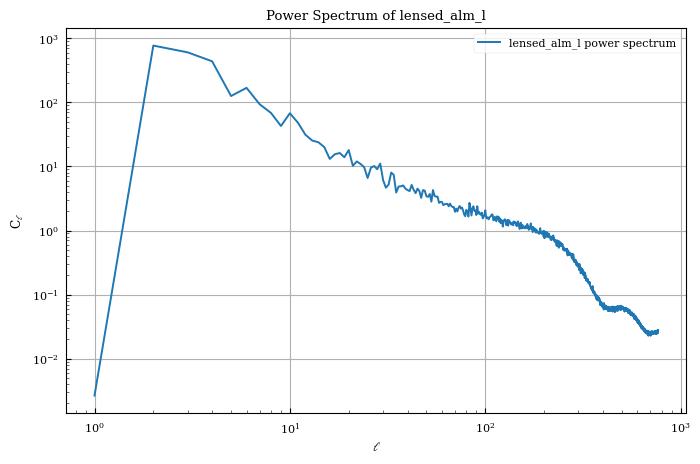

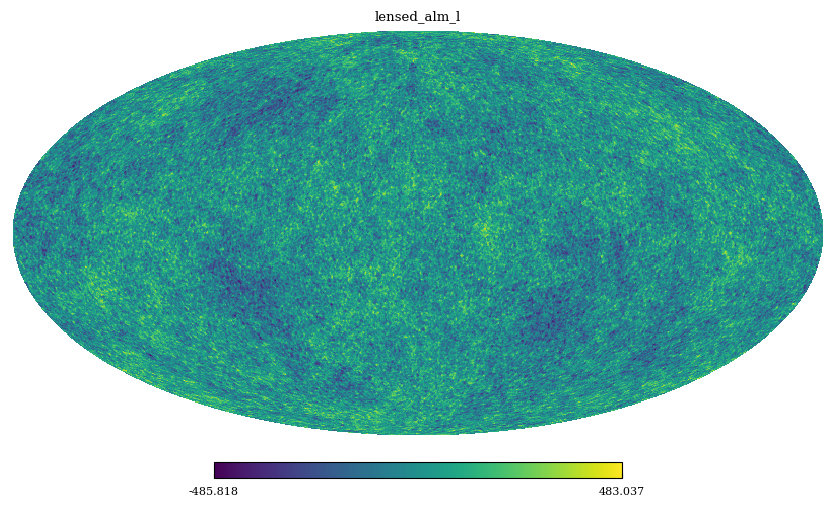

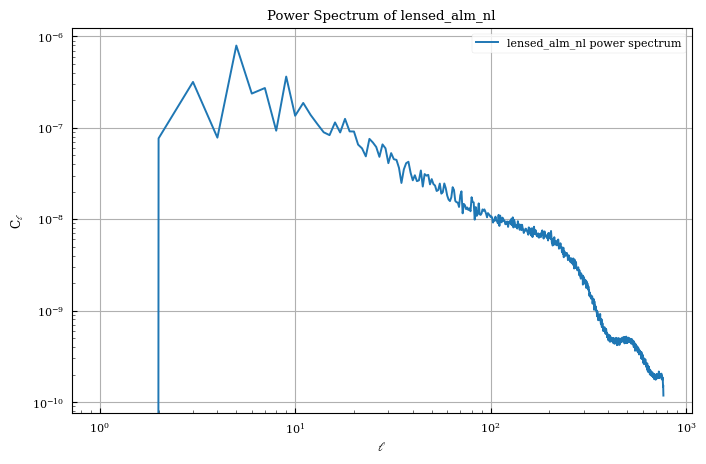

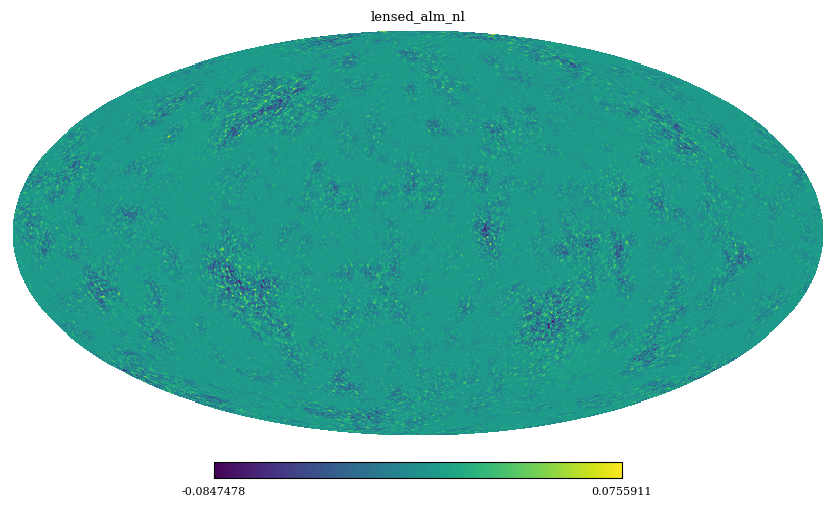

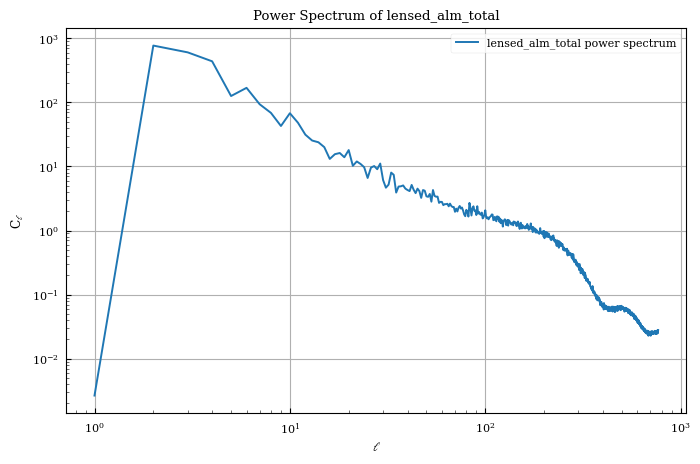

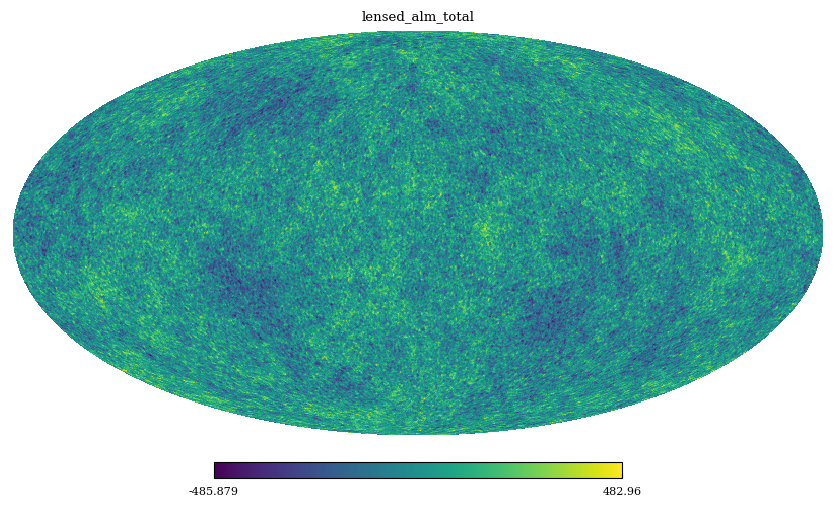

In [6]:
# plot the alm lensed data just to test
data_file = core.file

alm_l_lensed = get_data(data_file, "/alm_l/lensed", 0)
alm_nl_lensed = get_data(data_file, "/alm_nl/lensed/local", 0)

for alm, name in [
    (alm_l_lensed, "lensed_alm_l"),
    (alm_nl_lensed, "lensed_alm_nl"),
    (alm_l_lensed + alm_nl_lensed, "lensed_alm_total"),
]:
    alm = alm.astype(np.complex128)
    cl_alm = hp.alm2cl(alm)
    ell = np.arange(len(cl_alm[0]))

    plt.figure(figsize=(8, 5))
    plt.loglog(ell[1:], cl_alm[0, 1:], label=f"{name} power spectrum")
    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$C_\ell$")
    plt.title(f"Power Spectrum of {name}")
    plt.grid(True)
    plt.legend()
    plt.show()

    hp.mollview(
        hp.alm2map(alm[0], nside=core.nside, pol=False),
        title=f"{name}",
    )
    plt.show()

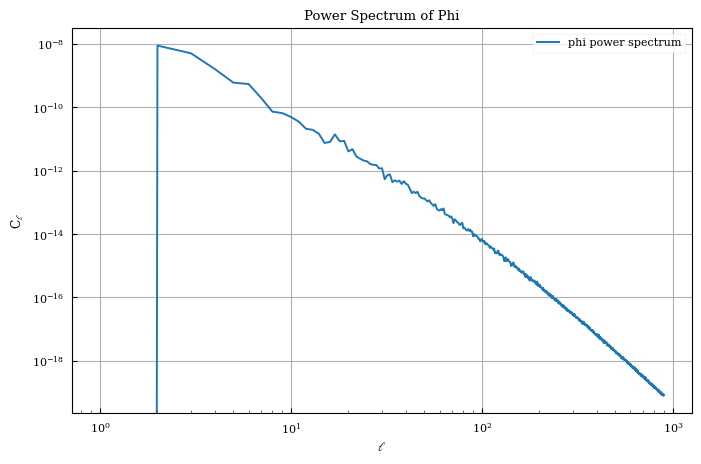

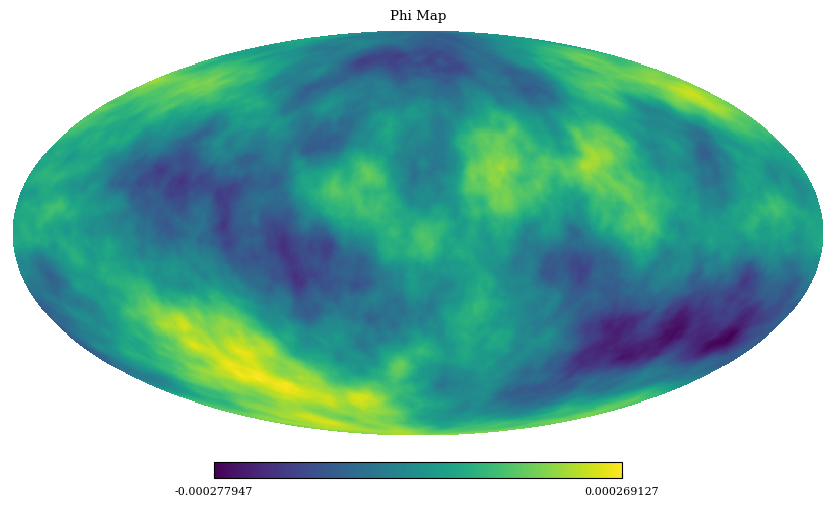

In [7]:
alm_phi = get_data(data_file, "/alm_phi", 0).astype(np.complex128)
cl_phi = hp.alm2cl(alm_phi)
ell = np.arange(cl_phi.shape[0])

plt.figure(figsize=(8, 5))
plt.loglog(ell[1:], cl_phi[1:], label=f"phi power spectrum")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.title(f"Power Spectrum of Phi")
plt.grid(True)
plt.legend()
plt.show()

hp.mollview(
    hp.alm2map(alm_phi, nside=core.nside, pol=False),
    title=f"Phi Map",
)
plt.show()

In [8]:
batch_size = 8
max_epochs = 100
initial_LR = 5e-3
decay_factor = 2

data_fraction = 0.01
unet_split = np.array([0.8, 0.1, 0.1]) * data_fraction
# unet_duplicates = [25, 10, 2]
unet_duplicates = [1, 1, 1]

# fnl values come from the
fnl_split = np.array([0.4, 0.1, 0.5]) * data_fraction
fnl_duplicates = [25, 10, 2]

final_split = np.array([0.8, 0.1, 0.1]) * 0.1  # * data_fraction
final_duplicates = [1, 1, 1]

strategy = tf.distribute.MirroredStrategy()  # use mirrored strategy for multi-GPU

In [9]:
# setup some common save file paths and cache paths

date_time = tf.timestamp().numpy().astype(int)
# date_time = "1762872069"  # freeze to one run to reuse the cache
run_name = f"notebook-{date_time}"
print("Run name:", run_name)

save_dir = f"{core.dirs['model']}/{core.name}"
run_info = f"{core.shapes_str()}-{run_name}"
plot_prefix = f"{core.dirs['plot']}/{core.name}/train/{core.slurm.job}"
os.makedirs(save_dir, exist_ok=True)
os.makedirs(f"{core.dirs['plot']}/{core.name}", exist_ok=True)
os.makedirs(os.path.dirname(plot_prefix), exist_ok=True)

# setups where we will
unet_keras_file = f"{save_dir}/unet-{run_info}.keras"
fnl_keras_file = f"{save_dir}/fnl-{run_info}.keras"

unet_cache = f"{core.name}/unet-{core.name}-f{data_fraction}"
fnl_cache = f"{core.name}/fnl-{core.name}-f{data_fraction}"

if os.path.exists(save_dir) is False:
    os.makedirs(save_dir, exist_ok=True)
    print(f"Created directory: {save_dir}")

for file in [unet_keras_file, fnl_keras_file]:
    print(f"file {file} exists: {os.path.exists(file)}")

Run name: notebook-1763654760
file data/models/l767_n256_T_10000_p1.0/unet-local-notebook-1763654760.keras exists: False
file data/models/l767_n256_T_10000_p1.0/fnl-local-notebook-1763654760.keras exists: False


In [10]:
# create the callbacks
callbacks = [
    TerminateOnNaN(),
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    # tf.keras.callbacks.BackupAndRestore(
    #     f"{core.dirs['model']}/chkpts",
    #     save_freq="epoch",
    #     delete_checkpoint=True,
    # ),
]

# if wanted we create a tensorboard and wandb callback, use the CLI to set these
tb_dir = f"{core.dirs['tb']}/{core.name}/{core.slurm.job}"
if core.use_tb:
    callbacks.append(
        TensorBoard(
            log_dir=tb_dir,
            histogram_freq=1,
            write_steps_per_second=True,
        )
    )

if core.use_wandb:
    try_init_wandb(
        config={
            "batch_size": batch_size,
            "max_epochs": max_epochs,
            "shapes": shapes,
            "learning_rate": repr(initial_LR),
        },
        dir=core.dirs["wandb"],
        append_to=callbacks,
        patch_tb=core.use_tb,
        patch_logdir=tb_dir,
    )

In [11]:
@tf.keras.saving.register_keras_serializable()
class EncoderBlock(tf.keras.layers.Layer):
    def __init__(
        self,
        nside,
        npix,
        fin,
        fout,
        activation,
        max_batch_size,
        K,
        use_bn=True,
        use_bias=False,
        pool=True,
        dropout_rate=0.1,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.nside = nside
        self.npix = npix
        self.fin = fin
        self.fout = fout
        self.activation_fn = activation
        self.max_batch_size = max_batch_size
        self.K = K
        self.use_bn = use_bn
        self.use_bias = use_bias
        self.dropout_rate = dropout_rate
        self.pool = pool

        enc_layers = [
            HealpyChebyshev(
                K=K,
                Fout=fout,
                activation=activation,
                use_bn=use_bn,
                use_bias=use_bias,
            ),
            HealpyChebyshev(
                K=K,
                Fout=fout,
                activation=activation,
                use_bn=use_bn,
                use_bias=use_bias,
            ),
        ]
        if dropout_rate > 0.0:
            enc_layers.append(Dropout(dropout_rate))

        self.body = HealpyGCNN(
            nside=nside,
            indices=np.arange(npix),
            layers=enc_layers,
            n_neighbors=8,
            max_batch_size=max_batch_size,
            initial_Fin=fin,
        )

        self.pooler = None
        if pool:
            self.pooler = HealpyGCNN(
                nside=nside,
                indices=np.arange(npix),
                layers=[HealpyPool(1, "MAX")],
                n_neighbors=8,
                max_batch_size=max_batch_size,
                initial_Fin=fin,
            )

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "nside": self.nside,
                "npix": self.npix,
                "fin": self.fin,
                "fout": self.fout,
                "activation": self.activation_fn,
                "max_batch_size": self.max_batch_size,
                "K": self.K,
                "use_bn": self.use_bn,
                "use_bias": self.use_bias,
                "pool": self.pool,
                "dropout_rate": self.dropout_rate,
            }
        )
        return config

    def call(self, inputs, training=False):
        x = skip = self.body(inputs, training=training)
        if self.pool:
            x = self.pooler(x, training=training)
        return x, skip


@tf.keras.saving.register_keras_serializable()
class DecoderBlock(tf.keras.layers.Layer):
    def __init__(
        self,
        nside,
        npix,
        fin,
        fout,
        activation,
        K,
        max_batch_size,
        upsample=True,
        use_bn=True,
        use_bias=False,
        dropout_rate=0.1,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.nside = nside
        self.npix = npix
        self.fin = fin
        self.fout = fout
        self.activation_fn = activation
        self.max_batch_size = max_batch_size
        self.K = K
        self.use_bn = use_bn
        self.use_bias = use_bias
        self.dropout_rate = dropout_rate
        self.upsample = upsample

        dec_layers = []
        if upsample:
            dec_layers.append(HealpyPseudoConv_Transpose(1, fout))

        dec_layers.extend(
            [
                HealpyChebyshev(
                    K=K,
                    Fout=fout,
                    activation=activation,
                    use_bn=use_bn,
                    use_bias=use_bias,
                ),
                HealpyChebyshev(
                    K=K,
                    Fout=fout,
                    activation=activation,
                    use_bn=use_bn,
                    use_bias=use_bias,
                ),
            ]
        )
        if dropout_rate > 0.0:
            dec_layers.append(Dropout(dropout_rate))

        self.body = HealpyGCNN(
            nside=nside,
            indices=np.arange(npix),
            layers=dec_layers,
            n_neighbors=8,
            max_batch_size=max_batch_size,
            initial_Fin=fin,
        )

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "nside": self.nside,
                "npix": self.npix,
                "fin": self.fin,
                "fout": self.fout,
                "activation": self.activation_fn,
                "K": self.K,
                "max_batch_size": self.max_batch_size,
                "upsample": self.upsample,
                "use_bn": self.use_bn,
                "use_bias": self.use_bias,
                "dropout_rate": self.dropout_rate,
            }
        )
        return config

    def call(self, inputs, skip, training=False):
        x = self.body(inputs, training=training)
        if skip is not None:
            x = x + skip
        return x


@tf.keras.saving.register_keras_serializable()
class ResidualHealpyUNet:
    def __init__(
        self,
        input_shape,
        activation="relu",
        max_batch_size=32,
        dropout_rate=0.1,
        use_bn=True,
        use_bias=True,
    ):
        self.input_shape = input_shape
        self.activation = activation
        self.max_batch_size = max_batch_size
        self.npix = input_shape[1]
        self.nside = hp.npix2nside(self.npix)
        self.npol = input_shape[2]
        self.dropout_rate = dropout_rate
        self.use_bn = use_bn
        self.use_bias = use_bias

    def get_config(self):
        return {
            "input_shape": self.input_shape,
            "activation": self.activation,
            "max_batch_size": self.max_batch_size,
            "dropout_rate": self.dropout_rate,
            "use_bn": self.use_bn,
            "use_bias": self.use_bias,
        }

    def get_model(self):
        depth = int(math.log2(self.nside))  # - 1

        base_channels = [self.npol] + [2 ** (i + 3) for i in range(depth + 1)]
        level_npixels = [self.npix // (4**i) for i in range(depth + 1)]
        level_nsides = [hp.npix2nside(npix) for npix in level_npixels]
        Ks = [1 + (2 * (1 + i // 3)) for i in range(depth + 1)]
        # Ks = [3 for _ in range(depth + 1)]
        logger.debug(f"Using Ks: {Ks}")

        inputs = tf.keras.Input(shape=self.input_shape[1:])
        x = inputs

        x = BatchNormalization()(x)

        skips = []
        for i in range(depth):
            block = EncoderBlock(
                level_nsides[i],
                level_npixels[i],
                fin=base_channels[i],
                fout=base_channels[i + 1],
                activation=self.activation,
                max_batch_size=self.max_batch_size,
                K=Ks[i],
                dropout_rate=self.dropout_rate,
                use_bias=self.use_bias,
                use_bn=self.use_bn,
            )
            x, skip = block(x)
            skips.append(skip)

        bottleneck = HealpyGCNN(
            nside=level_nsides[depth],
            indices=np.arange(level_npixels[depth]),
            layers=[
                HealpyChebyshev(
                    K=Ks[-1],
                    Fout=base_channels[-1],
                    activation=self.activation,
                    use_bias=self.use_bias,
                    use_bn=self.use_bn,
                ),
                HealpyChebyshev(
                    K=Ks[-1],
                    Fout=base_channels[-1],
                    activation=self.activation,
                    use_bias=self.use_bias,
                    use_bn=self.use_bn,
                ),
            ],
            n_neighbors=8,
            max_batch_size=self.max_batch_size,
            initial_Fin=base_channels[-1],
            name="bottleneck",
        )
        x = bottleneck(x)

        for i in reversed(range(1, depth + 1)):
            block = DecoderBlock(
                level_nsides[i],
                level_npixels[i],
                fin=base_channels[i],
                fout=base_channels[i],
                activation=self.activation,
                max_batch_size=self.max_batch_size,
                K=Ks[i],
                dropout_rate=self.dropout_rate,
                use_bias=self.use_bias,
                use_bn=self.use_bn,
            )
            x = block(x, skips[i - 1])

        # final block to account for upscaling to phi
        block = DecoderBlock(
            level_nsides[0],
            level_npixels[0],
            fin=base_channels[0],
            fout=base_channels[1] // 2,
            activation=self.activation,
            max_batch_size=self.max_batch_size,
            K=Ks[0],
            dropout_rate=0.0,
            use_bias=self.use_bias,
            use_bn=self.use_bn,
        )
        x = block(x, None)

        # output
        output_head = HealpyGCNN(
            nside=self.nside,
            indices=np.arange(self.npix),
            layers=[
                HealpyChebyshev(
                    K=1,
                    Fout=base_channels[0],
                    activation=None,
                    use_bn=False,
                    use_bias=True,
                ),
            ],
            n_neighbors=8,
            max_batch_size=self.max_batch_size,
            initial_Fin=self.npol,
            name="output",
        )
        outputs = output_head(x)
        return tf.keras.Model(inputs, outputs)

In [ ]:
if not os.path.exists(unet_keras_file):
    logger.debug(f"U-Net file '{unet_keras_file}' does not exist, creating new U-Net")
    logger.info("Creating U-Net model and training data")

    # calculate the number of steps per epoch and decay steps for use later
    epoch_steps = math.ceil(
        core.total_sims * unet_split[0] * unet_duplicates[0] // batch_size
    )
    decay_steps = epoch_steps * 2  # * decay_factor
    print("Steps per epoch:", epoch_steps)

    with strategy.scope():
        learning_rate = ExponentialDecay(5e-3, decay_steps, 0.98, staircase=True)

        u_net = ResidualHealpyUNet(
            (None, core.npix, core.npols),
            activation="gelu",
            max_batch_size=batch_size,
        ).get_model()

        u_net.compile(
            optimizer=AdamW(learning_rate, weight_decay=5e-8, amsgrad=True),
            loss="mse",  # RMSELoss(),  # PowerSpectrumLoss2(core.lmax),
            metrics=rmse_metrics(shapes) + ["mse", "mae"],
        )
else:
    logger.info("Loading U-Net from file: '%s'", unet_keras_file)
    u_net = tf.keras.models.load_model(unet_keras_file)

20-Nov-25 10:06:00 - mlpng.notebook - DEBUG - U-Net file 'data/models/l767_n256_T_10000_p1.0/unet-local-notebook-1763654760.keras' does not exist, creating new U-Net
20-Nov-25 10:06:00 - mlpng.notebook - INFO - Creating U-Net model and training data
Steps per epoch: 10
20-Nov-25 10:06:00 - mlpng.notebook - DEBUG - Using Ks: [3, 3, 3, 5, 5, 5, 7, 7, 7]
20-Nov-25 10:06:00 - mlpng.notebook - INFO - Creating U-Net model and training data
Steps per epoch: 10
20-Nov-25 10:06:00 - mlpng.notebook - DEBUG - Using Ks: [3, 3, 3, 5, 5, 5, 7, 7, 7]


In [ ]:
u_net.summary()

In [ ]:
ds = PhiMapDataset.fromCore(core, lensed=True)

train, val, test = ds.split(
    train_size=unet_split[0],
    val_size=unet_split[1],
    test_size=unet_split[2],
    to_tf=True,
    batch_size=batch_size,
    duplicates=unet_duplicates,
    # cache_file=unet_cache,
    gen_batch_size=core.slurm.n_cpus,
)

In [ ]:
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(train.map(lambda x, y: y))


def normalize_y(x, y):
    return x, normalizer(y)


def undo_norm(y):
    val = y * tf.sqrt(normalizer.variance) + normalizer.mean
    return val.numpy()


train = train.map(normalize_y)
val = val.map(normalize_y)
# test = test.map(normalize_y)

In [ ]:
# get this data that we will need later, also serves to create the test data
# this allows us to have the full cached dataset by the end of the first epoch
# if the cache exists this is very fast
if not os.path.exists(unet_keras_file):
    logger.debug("Creating test cache")
    y_test = np.concatenate([y for _, y in test])
    logger.debug("Test cache created")

In [ ]:
if not os.path.exists(unet_keras_file):
    logger.debug("Creating val cache")
    for _ in val:
        pass
    logger.debug("Val cache created")

In [ ]:
# just generate the training data for one epoch to fill the cache
# this might speed up training for the first epoch
if not os.path.exists(unet_keras_file):
    logger.debug("Creating train cache")
    for _ in train:
        pass
    logger.debug("Train cache created")

In [ ]:
# and finally we fit the model
if not os.path.exists(unet_keras_file):
    history = u_net.fit(
        train,
        epochs=3,
        validation_data=val,
        callbacks=callbacks,
        verbose=1,
    )

stop

## test save / load model

In [ ]:
if not os.path.exists(unet_keras_file):
    u_net.save(unet_keras_file)

    # just test loading the model
    with strategy.scope():
        u_net = tf.keras.models.load_model(unet_keras_file)

    print(
        "U-Net model reloaded from file successfully. Removing model file for the notebook."
    )
    os.remove(unet_keras_file)

### test u_net

In [ ]:
test_phi = np.concatenate([y for _, y in test])[0, :, 0]
pred_phi = u_net.predict(test, verbose=0)

# test_phi = undo_norm(test_phi)[0, :, 0]
pred_phi = undo_norm(pred_phi)[0, :, 0]

test_phi_ring = hp.reorder(test_phi, n2r=True)
pred_phi_ring = hp.reorder(pred_phi, n2r=True)

for map, name in [(test_phi_ring, "True"), (pred_phi_ring, "Predicted")]:
    hp.mollview(
        map,
        title=f"{name} phi map",
        unit="phi",
        cmap="viridis",
        norm="hist",
        # remove_dip=True,
    )
    plt.show()

hp.mollview(test_phi - pred_phi, title="Residual (Nest)", cmap="RdBu_r")
plt.show()

hp.mollview(test_phi_ring - pred_phi_ring, title="Residual (Ring)", cmap="RdBu_r")
plt.show()

plt.figure()
for map, name in [(test_phi_ring, "True"), (pred_phi_ring, "Predicted")]:
    cl = hp.anafast(
        hp.remove_dipole(map), lmax=core.lmax, pol=False, use_pixel_weights=True
    )
    plt.loglog(cl, label=name)
plt.legend()
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell^{\phi\phi}$")
plt.show()

plt.figure()
for map, name in [(test_phi, "True (nest)"), (pred_phi, "Predicted (nest)")]:
    cl = hp.anafast(
        hp.remove_dipole(map), lmax=core.lmax, pol=False, use_pixel_weights=True
    )
    plt.loglog(cl, label=name)
plt.legend()
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell^{\phi\phi}$")
plt.show()

# make fnl model based on new data

In [ ]:
ds_2 = MapDataset.fromCore(core, lensed=False)
train_2, val_2, test_2 = ds_2.split(
    train_size=fnl_split[0],
    val_size=fnl_split[1],
    test_size=fnl_split[2],
    to_tf=True,
    batch_size=batch_size,
    duplicates=fnl_duplicates,
    cache_file=fnl_cache,
    gen_batch_size=core.slurm.n_cpus,
)

if not os.path.exists(fnl_keras_file):
    # the paper does not rotate the test set
    test_2.rotate = False

    logger.debug("Creating fnl caches")
    for _ in train_2:
        pass
    logger.debug("Fnl train cache created")
    for _ in val_2:
        pass
    logger.debug("Fnl val cache created")
    for _ in test_2:
        pass
    logger.debug("Fnl caches created")

    # calculate the number of steps per epoch and decay steps for use later
    epoch_steps = math.ceil(
        core.total_sims * fnl_split[0] * fnl_duplicates[0] // batch_size
    )
    decay_steps = epoch_steps * 3

    with strategy.scope():
        learning_rate = ExponentialDecay(initial_LR, decay_steps, 0.95, staircase=True)

        fnl_model = get_fnl_model(
            (None, core.npix, core.npols), batch_size, len(shapes)
        )

        fnl_model.compile(
            optimizer=AdamW(learning_rate),
            loss=RMSELoss(),
            metrics=rmse_metrics(shapes),
        )

    # fnl_model.summary()

    # and finally we fit the model
    fnl_history = fnl_model.fit(
        train_2,
        epochs=max_epochs,
        validation_data=val_2,
        callbacks=callbacks,
        verbose=1,
    )

    # logger.info("Saving model to %s", fnl_keras_file)
    # fnl_model.save(fnl_keras_file)
else:
    logger.info("Loading model from %s", fnl_keras_file)
    fnl_model = tf.keras.models.load_model(fnl_keras_file)

In [ ]:
# plot the test results for model 2, make sure it does not pass the KR bound

# Check Melsen for the expected bounds, reproduce results
# | nside | Full | Gaussian |
# |------:|-----:|---------:|
# | 32    |   95 |      103 |
# | 64    |   56 |       52 |
# | 128   |   33 |       28 |

In [ ]:
fnl_2_truth = np.concatenate([y for _, y in test_2])
fnl_2_preds = fnl_model.predict(test_2, verbose=0)

In [ ]:
vals = fnl_2_truth.ravel()
plt.figure(figsize=(6, 4))
plt.hist(vals, bins=50, color="C0", alpha=0.8)
plt.xlabel("fnl (truth)")
plt.ylabel("Count")
plt.title(f"Distribution of test_2 truth values (N={vals.size})")
plt.tight_layout()
plt.show()

In [ ]:
# fnl_2_truth = np.array(fnl_2_truth).reshape(-1, 1)
print(fnl_2_preds.shape)

# Calculate metrics
fnl_error = fnl_2_preds - fnl_2_truth
print(f"Mean absolute error: {np.mean(np.abs(fnl_error)):.4f}")
print(f"RMSE: {np.sqrt(np.mean(fnl_error**2)):.4f}")

line = np.array([np.nanmin(fnl_2_truth), np.nanmax(fnl_2_truth)])
sigma = core.get_likelihoods(False)[0]

# Plot results
plt.figure(figsize=(16, 4))

plt.subplot(131)
plt.scatter(fnl_2_truth, fnl_2_preds, alpha=0.5)
plt.plot(line, line, "r--")
plt.plot(line, line + sigma, "g--")
plt.plot(line, line - sigma, "g--")
plt.xlabel("True fnl")
plt.ylabel("Predicted fnl")
plt.title("fnl Prediction from unlensed Maps")

plt.subplot(132)
plt.hist(fnl_error, bins=50)
plt.axvline(sigma, color="g", linestyle="--", label=f"+σ={sigma:.2f}")
plt.axvline(-sigma, color="g", linestyle="--", label=f"-σ={-sigma:.2f}")
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("fnl Error Distribution")

plt.subplot(133)
plt.plot(fnl_2_preds, alpha=0.7, label="Predicted")
plt.plot(fnl_2_truth, alpha=0.7, label="True")
plt.xlabel("Sample Index")
plt.ylabel("fnl Value")
plt.title("fnl Values Over Test Set")
plt.legend()

plt.tight_layout()
plt.show()

# delens maps to connect the models

In [ ]:
ds_3 = MapDataset.fromCore(core, lensed=True)
train_3, val_3, test_3 = ds_3.split(
    train_size=final_split[0],
    val_size=final_split[1],
    test_size=final_split[2],
    to_tf=True,
    batch_size=batch_size,
    duplicates=final_duplicates,
    gen_batch_size=core.slurm.n_cpus,
)

print("Creating test_3 cache")
fnl_truth = np.concatenate([y for _, y in test_3])
print("Done")

In [ ]:
res_arcmin = hp.nside2resol(core.nside, arcmin=True)
res_rad = res_arcmin * utils.arcmin

# snap to nearest resolution that evenly divides the sky (vertical)
ny = int(round(np.pi / res_rad))
res_fixed = np.pi / ny  # exact divisor for π
print(
    f"healpy res (arcmin) = {res_arcmin:.6f}, using fixed res (arcmin) = {res_fixed / utils.arcmin:.6f}"
)

# build geometry with the fixed resolution
shape, wcs = enmap.fullsky_geometry(res_fixed)


def _delens_py(lensed, phi, nside=core.nside):
    delensed_maps = np.zeros_like(lensed)
    # TODO test joblib parallel here
    for i, (l_map, p_map) in enumerate(zip(lensed, phi)):
        l_map = hp.reorder(l_map.numpy()[:, 0], n2r=True).astype(np.float32)
        p_map = hp.reorder(p_map.numpy()[:, 0], n2r=True).astype(np.float32)

        lensed_enmap = reproject.healpix2map(l_map, shape, wcs)
        phi_enmap = reproject.healpix2map(p_map, shape, wcs)
        delensed_enmap = lensing.delens_map(lensed_enmap, phi_enmap)

        m = reproject.map2healpix(delensed_enmap, nside)
        m = hp.remove_dipole(m, copy=False)
        delensed_maps[i] = m[:, None]

    return delensed_maps


def _map_fn(pair, phi):
    lensed, fnls = pair
    delensed = tf.py_function(
        func=_delens_py,
        inp=[lensed, phi],
        Tout=tf.float32,
    )

    delensed.set_shape([None, core.npix, core.npols])
    fnls.set_shape([None, len(shapes)])
    return delensed, fnls


phi_preds = u_net.predict(test_3, verbose=0)
phi_preds = undo_norm(phi_preds)
phi_ds = tf.data.Dataset.from_tensor_slices(phi_preds).batch(batch_size)
delensed_ds = (
    tf.data.Dataset.zip((test_3, phi_ds))
    .map(_map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()  # just cache here to ensure no mixing of the datasets on future reads
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
for map, _ in delensed_ds.take(1):
    m = map[0, :, 0].numpy()
    print(m[:10])
    # m = hp.reorder(m, n2r=True)
    m = hp.remove_dipole(m, copy=False)
    hp.mollview(
        m,
        title="Delensed map",
        unit="T",
        cmap="viridis",
    )
    plt.show()

    plt.figure()
    cl = hp.anafast(m, lmax=core.lmax, pol=False, use_pixel_weights=True)
    plt.loglog(cl, label="Delensed")
    plt.legend()
    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$C_\ell$")
    plt.show()

In [ ]:
fnl_preds = fnl_model.predict(test_3, verbose=1)

In [ ]:
fnl_truth = np.concatenate([y for _, y in delensed_ds])

In [ ]:
fnl_truth = fnl_truth.ravel()
fnl_preds = fnl_preds.ravel()

print("True fnls shape:", fnl_truth.shape)
print("Predicted fnls shape:", fnl_preds.shape)

# Calculate metrics
fnl_error = fnl_preds - fnl_truth
print(f"Mean absolute error: {np.mean(np.abs(fnl_error)):.4f}")
print(f"RMSE: {np.sqrt(np.mean(fnl_error**2)):.4f}")

line = np.array([np.nanmin(fnl_truth), np.nanmax(fnl_truth)])
sigma = core.get_likelihoods(True)[0]
# Plot results
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.scatter(fnl_truth, fnl_preds, alpha=0.5)
plt.plot(line, line, "r--")
plt.plot(line, line + sigma, "g--")
plt.plot(line, line - sigma, "g--")
plt.xlabel("True fnl")
plt.ylabel("Predicted fnl")
plt.title("fnl Prediction from Delensed Maps")

plt.subplot(132)
plt.hist(fnl_error, bins=50)
plt.axvline(sigma, color="g", linestyle="--", label=f"+σ={sigma:.2f}")
plt.axvline(-sigma, color="g", linestyle="--", label=f"-σ={-sigma:.2f}")
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("fnl Error Distribution")

plt.subplot(133)
plt.plot(fnl_preds, alpha=0.7, label="Predicted")
plt.plot(fnl_truth, alpha=0.7, label="True")
plt.xlabel("Sample Index")
plt.ylabel("fnl Value")
plt.title("fnl Values Over Test Set")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
vals = fnl_truth.ravel()  # assumes fnl_truth exists from earlier cell

plt.figure(figsize=(6, 4))
plt.hist(vals, bins=50, color="C0", alpha=0.8)
plt.xlabel("fnl (truth)")
plt.ylabel("Count")
plt.title(f"Distribution of test_3 truth values (N={vals.size})")
plt.tight_layout()
plt.show()